<a href="https://colab.research.google.com/github/KowshiqKatta/Fundamentals-of-Gen-AI-and-LLM/blob/main/Fundamentals/Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Load Document

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# normalize the pixel values to [0, 1]
x_train = x_train/255.0
x_test = x_test/255.0

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Training data shape: ", x_train.shape)
print("Testing data shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1835s 11us/step
Training data shape:  (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


## Ensemble model

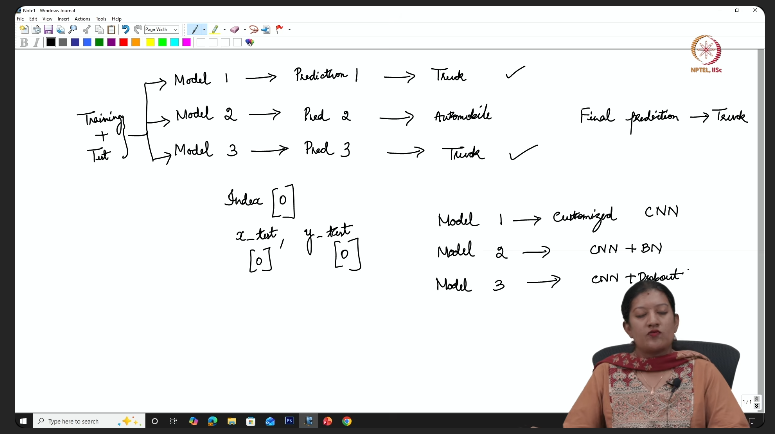

Define Model 1

In [5]:
def create_cnn1():

  model = tf.keras.Sequential([
      layers.Conv2D(32, (3, 3), activation = 'relu',
                    input_shape = (32, 32, 3)),
      layers.MaxPooling2D((2, 2)),

      layers.Conv2D(64, (3, 3), activation = 'relu'),
      layers.MaxPooling2D((2, 2)),

      layers.Flatten(),
      layers.Dense(128, activation = 'relu'),
      layers.Dense(10, activation = 'softmax')
  ])

  return model


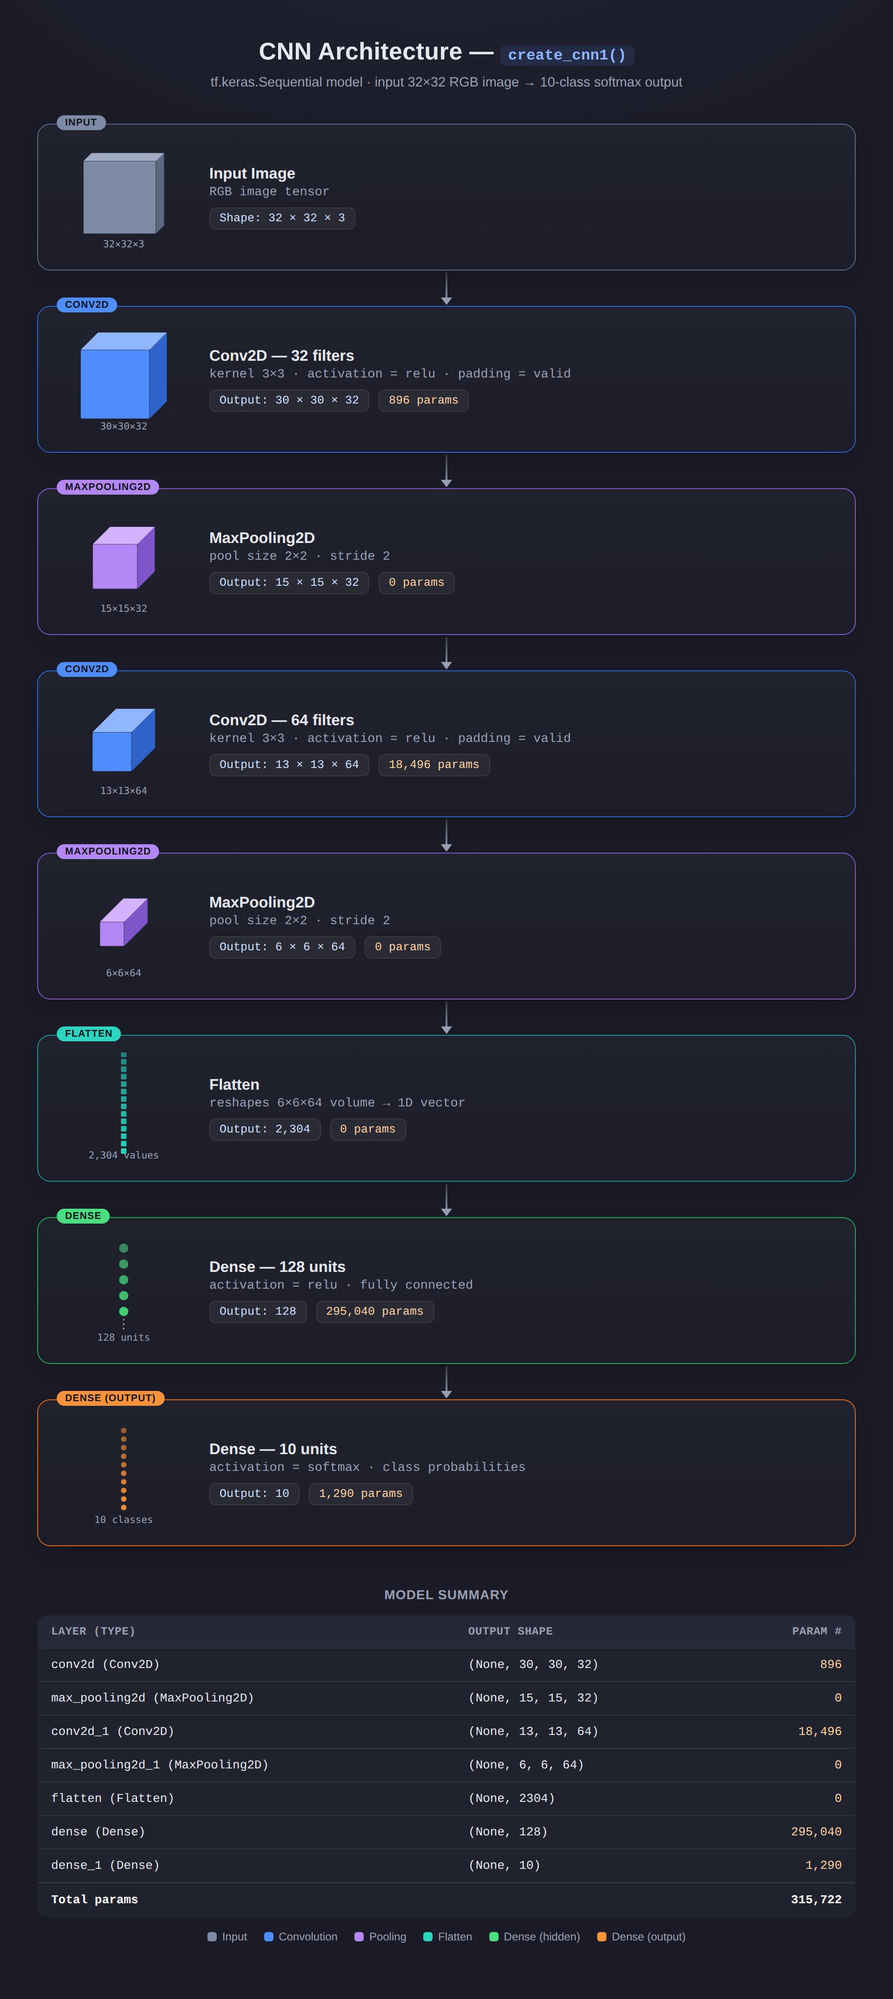

Define Model 2

In [10]:
def create_cnn2():

  model = tf.keras.Sequential([
      layers.Conv2D(32, (3, 3), input_shape = (32, 32, 3)),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.MaxPooling2D((2, 2)),

      layers.Conv2D(64, (3, 3)),
      layers.BatchNormalization(),
      layers.Activation('relu'),
      layers.MaxPooling2D((2, 2)),

      layers.Flatten(),
      layers.Dense(128, activation = 'relu'),
      layers.Dense(10, activation = 'softmax')
  ])

  return model

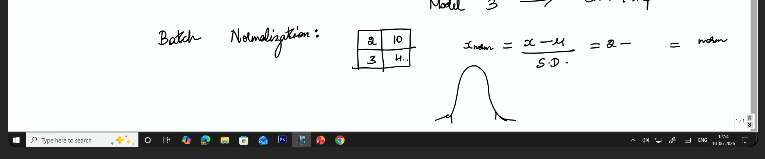

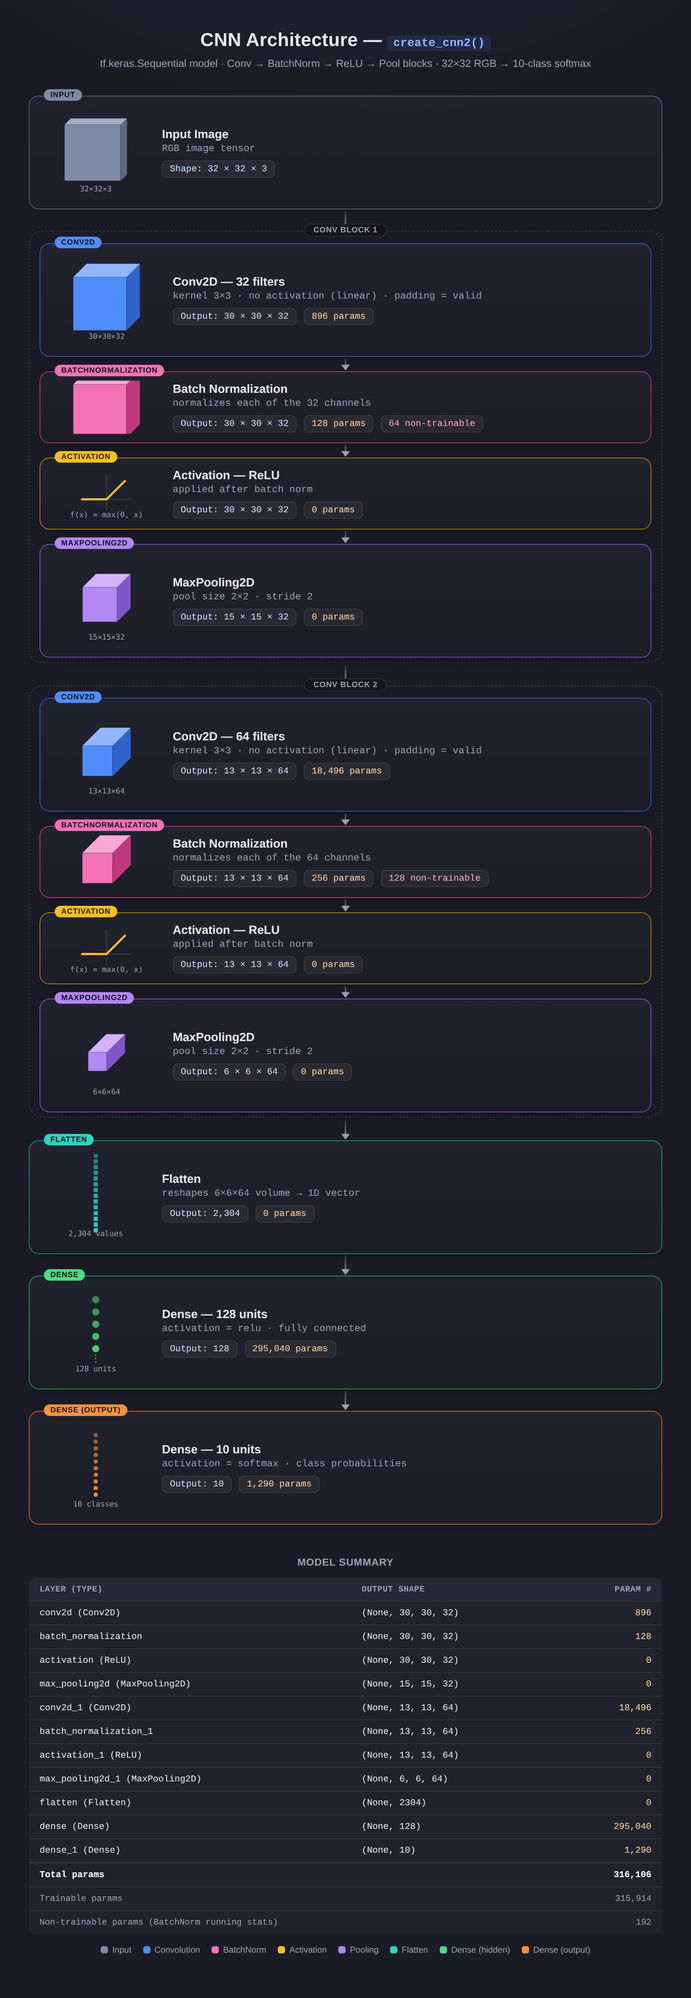

Define Model 3

In [7]:
def create_cnn3():

  model = tf.keras.Sequential([
      layers.Conv2D(32, (3, 3), activation = 'relu',
                    input_shape = (32, 32, 3)),
      layers.MaxPooling2D((2, 2)),

      layers.Conv2D(64, (3, 3), activation = 'relu'),
      layers.MaxPooling2D((2, 2)),

      layers.Flatten(),

      layers.Dense(128, activation = 'relu'),

      layers.Dropout(0.5),

      layers.Dense(10, activation = 'softmax')
  ])

  return model

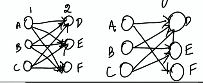

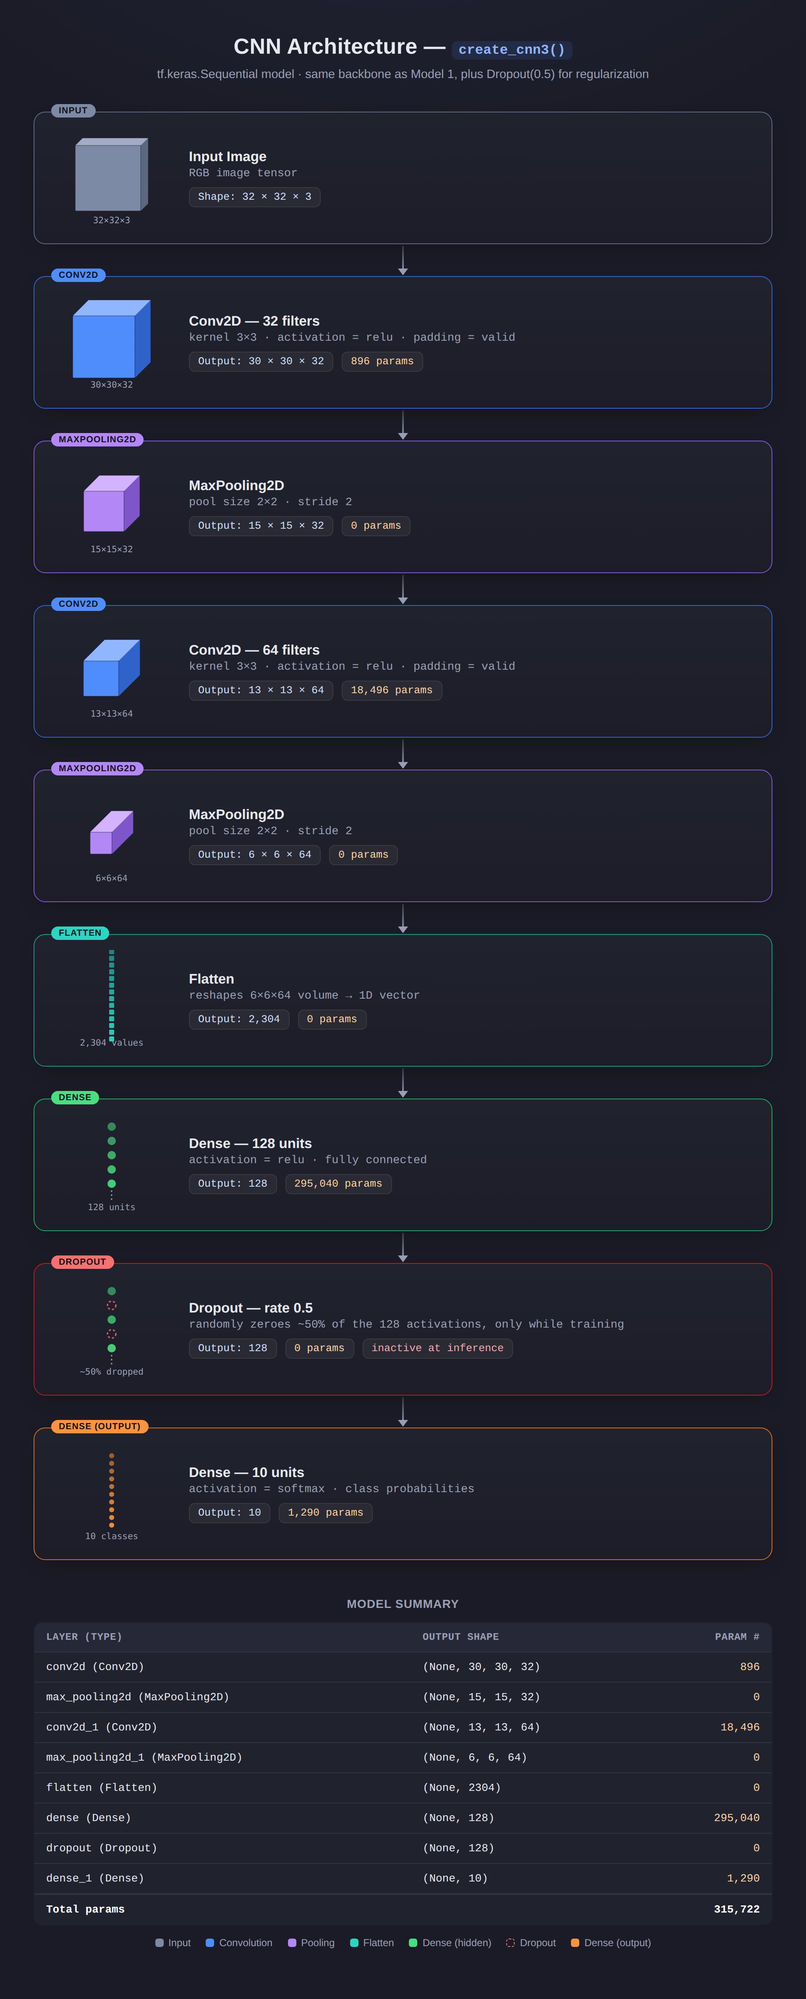

Build Ensemble Model

In [11]:
model1 = create_cnn1()
model2 = create_cnn2()
model3 = create_cnn3()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
for model in [model1, model2, model3]:
  model.compile(
      optimizer = 'adam',
      loss = 'sparse_categorical_crossentropy',
      metrics = ['accuracy']
  )

In [13]:
history1 = model1.fit(
    x_train, y_train,
    epochs = 5,
    batch_size = 64,
    validation_split = 0.2
)

history2 = model2.fit(
    x_train, y_train,
    epochs = 5,
    batch_size = 64,
    validation_split = 0.2
)

history3 = model3.fit(
    x_train, y_train,
    epochs = 5,
    batch_size = 64,
    validation_split = 0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 92ms/step - accuracy: 0.4547 - loss: 1.5158 - val_accuracy: 0.5405 - val_loss: 1.2753
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 88ms/step - accuracy: 0.5969 - loss: 1.1472 - val_accuracy: 0.6248 - val_loss: 1.0840
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.6514 - loss: 1.0036 - val_accuracy: 0.6236 - val_loss: 1.0868
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 90ms/step - accuracy: 0.6846 - loss: 0.9062 - val_accuracy: 0.6739 - val_loss: 0.9403
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.7126 - loss: 0.8250 - val_accuracy: 0.6855 - val_loss: 0.9129
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 128ms/step - accuracy: 0.5028 - loss: 1.3875 - val_accuracy: 0.4477 - val_loss: 1.6147
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.6386 - loss: 1.0320 - val_accuracy: 0.5705 - val_loss: 1.2494
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.6760 - loss: 0.9239 - val_a

Predictions

In [14]:
pred1 = model1.predict(x_test)
pred2 = model2.predict(x_test)
pred3 = model3.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [15]:
ensemble_pred = (
    pred1 + pred2 + pred3
)/3

In [16]:
y_pred = np.argmax(ensemble_pred, axis = 1)

Ensemble Accuracy

In [17]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_test,
    y_pred
)

print("Ensemble Accuracy: ", acc)

Ensemble Accuracy:  0.6859


Confusion Matrix

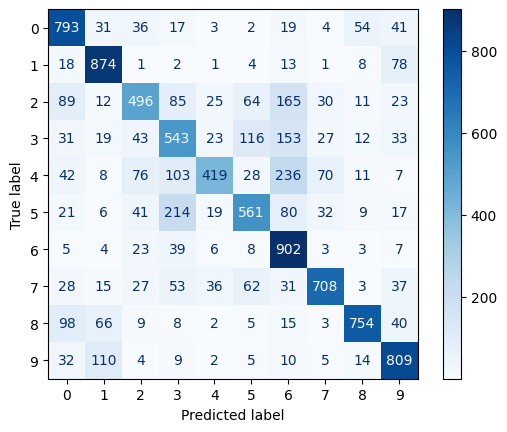

In [18]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
)

disp.plot(cmap = 'Blues')

plt.show()